# Should This Engine Get a Compressor Wash — and How Often?
### An aerospace/MRO project built on *Causal Inference in Python*, Chapter 7 — "Metalearners"

**Business context.** You're a reliability/MRO (Maintenance, Repair &
Overhaul) data scientist at an airline. Jet engines gradually **foul**:
dust, sand, salt, and combustion residue build up on compressor blades,
raising internal temperatures for a given thrust setting. This shows up as
**EGT margin loss** (Exhaust Gas Temperature margin — the buffer between
normal operating temperature and the temperature limit that forces an
engine removal) and as **higher specific fuel consumption (SFC)** — the
engine burns more fuel to do the same work. A **compressor wash**
(injecting a cleaning fluid to physically remove deposits) can partially
reverse fouling — but it costs aircraft-on-ground time and MRO labor, so
you can't wash every engine constantly. Two live decisions:

1. **Binary treatment — enroll this engine in the preventive wash program
   or not?** Some engines are already enrolled, but **not randomly**:
   maintenance planners preferentially enrolled engines that fly **dusty,
   high-utilization routes** (because those are the obvious candidates) —
   which also happen to be the engines that degrade fastest for other
   reasons, too. That's confounding. You also have a small **randomized
   pilot trial** (wash assignment by coin flip on a subset of the fleet)
   you can use purely for evaluation. Question: *for which engines does
   enrollment actually save the most EGT margin, and — given limited MRO
   shop-visit slots — which engines should be enrolled first?*
   → **T-Learner / X-Learner** territory.

2. **Continuous treatment — how many washes per 500 flight cycles?**
   Historically wash *interval* was **not randomized** either: planners
   wash high-fouling-trend engines more often (a "chase the problem"
   policy), which confounds any naive regression of fuel-efficiency gain on
   wash frequency. You also have a small **randomized** interval trial for
   evaluation. Question: *what's each engine's fuel-efficiency
   dose-response curve, and what's the efficiency-maximizing wash interval
   per engine, given a fixed total wash-hours budget across the fleet?*
   → **S-Learner / R-Learner (Double-ML)** territory.

**Structure**, mirroring the chapter and the previous case studies:

- Part 1 — simulate a confounded wash-program-enrollment dataset + a
  randomized pilot-trial holdout.
- Part 2 — T-Learner and X-Learner, evaluated with the **cumulative gain
  curve**; reproduce the book's **regularization-bias experiment** using a
  realistic **small-fleet pilot trial** (a new program almost always starts
  on a handful of aircraft before fleet-wide rollout).
- Part 3 — simulate confounded wash-interval data (continuous treatment) +
  a randomized holdout.
- Part 4 — S-Learner (counterfactual dose-response curves) and R-Learner /
  Double-ML (direct marginal-effect estimation) for the continuous case.
- Part 5 — turn both into MRO operating decisions: a shop-visit-slot
  constrained enrollment plan, and a wash-hours-budget-constrained interval
  policy — plus a decision-guide summary.

> As before, all data is **simulated with a known causal structure**
> (confounding + heterogeneous effects + a randomized holdout for honest
> evaluation), so every learner can be checked against ground truth.


## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from lightgbm import LGBMRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_predict
import statsmodels.api as sm
from toolz import curry

np.random.seed(123)
pd.set_option("display.max_columns", 20)
plt.rcParams["figure.figsize"] = (7, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3


# Part 1 — Data: the compressor-wash enrollment program

`data_program` is a **large, confounded** dataset (300,000 engine-months
across the fleet): whether an engine is enrolled in the preventive wash
program depends on how dusty/harsh its typical routes are and how utilized
it is — exactly the traits maintenance planners can already observe and
that *also* drive baseline degradation. `data_pilot` is a **small,
randomized** trial (10,000 engine-months) where wash enrollment was
assigned by coin flip — used **only for evaluation**.

**Covariates:**
- `engine_cycles` — total cycles since new (proxy for age/wear)
- `particulate_index` — 0–10 score of how dusty/sandy/salty the engine's
  typical routes are (desert, coastal, unpaved-strip operations score
  high)
- `avg_takeoff_temp_c` — average ambient takeoff temperature (thermal
  stress proxy)
- `cycles_per_month` — utilization rate
- `pct_derated_takeoffs` — share of takeoffs flown at reduced (derated)
  thrust; **higher derate = gentler operation**, so this *protects* the
  engine

**Outcome:** `egt_margin_retained_c` — EGT margin (°C) retained over the
next 500 cycles (higher is better; fouling erodes this margin).

**True effect design:** wash enrollment helps most for engines with **high
particulate exposure** and **high utilization** — the engines accumulating
fouling fastest have the most margin to recover from a wash. This mirrors
the real physics: you can't "clean" thermal fatigue or metallurgical wear,
only fouling-driven margin loss.


In [2]:
def simulate_engines(n, seed):
    rng = np.random.default_rng(seed)
    engine_cycles = rng.exponential(6000, n).clip(200, 30000)
    particulate_index = rng.beta(2, 3, n) * 10          # 0-10, skewed toward moderate
    avg_takeoff_temp_c = rng.normal(28, 8, n).clip(0, 48)
    cycles_per_month = rng.gamma(4, 25, n).clip(10, 400)
    pct_derated_takeoffs = rng.beta(2, 2, n)            # 0-1 share

    return pd.DataFrame(dict(
        engine_cycles=engine_cycles,
        particulate_index=particulate_index,
        avg_takeoff_temp_c=avg_takeoff_temp_c,
        cycles_per_month=cycles_per_month,
        pct_derated_takeoffs=pct_derated_takeoffs,
    ))


def assign_wash_program(X, rng):
    # Planners enroll dusty, high-utilization engines first -> confounding,
    # since those same traits predict faster baseline degradation.
    logit = (
        -2.0
        + 0.28 * X["particulate_index"]
        + 0.004 * X["cycles_per_month"]
        + 0.00003 * X["engine_cycles"]
    )
    p = (1 / (1 + np.exp(-logit))).clip(0.02, 0.97)
    T = rng.binomial(1, p)
    return T, p


def true_cate_wash(X):
    # Biggest winners: high particulate exposure + high utilization
    # (fastest fouling accumulation -> most margin recoverable by a wash).
    effect = (
        0.4
        + 0.55 * X["particulate_index"]
        + 0.015 * X["cycles_per_month"]
    )
    return effect.clip(lower=0)


def simulate_egt_margin(X, T, rng):
    tau = true_cate_wash(X)
    baseline = (
        22.0
        - 0.0006 * X["engine_cycles"]
        - 0.55 * X["particulate_index"]
        - 0.05 * X["avg_takeoff_temp_c"]
        - 0.01 * X["cycles_per_month"]
        + 3.0 * X["pct_derated_takeoffs"]
    )
    noise = rng.normal(0, 1.8, len(X))
    Y = (baseline + T * tau + noise).clip(lower=0)
    return Y, tau


rng = np.random.default_rng(123)

# --- Large, confounded wash-program data ---
X_prog = simulate_engines(300_000, seed=41)
T_prog, ps_true = assign_wash_program(X_prog, rng)
Y_prog, tau_prog = simulate_egt_margin(X_prog, T_prog, rng)
data_program = X_prog.assign(wash_program=T_prog, egt_margin_retained_c=Y_prog)

# --- Small randomized pilot trial, evaluation only ---
X_pilot = simulate_engines(10_000, seed=42)
T_pilot = rng.binomial(1, 0.5, len(X_pilot))
Y_pilot, tau_pilot_true = simulate_egt_margin(X_pilot, T_pilot, rng)
data_pilot = X_pilot.assign(wash_program=T_pilot, egt_margin_retained_c=Y_pilot, true_cate=tau_pilot_true)

print(len(data_program), len(data_pilot))
data_pilot.head()


300000 10000


,engine_cycles,particulate_index,avg_takeoff_temp_c,cycles_per_month,pct_derated_takeoffs,wash_program,egt_margin_retained_c,true_cate
0,14425.251624,1.775033,31.908493,72.858614,0.622145,1,16.826617,2.469147
1,14017.137935,6.705541,24.449461,135.587442,0.725451,0,11.160767,6.121859
2,14308.565999,3.503874,34.571714,252.745810,0.220073,1,12.986468,6.118318
3,1678.765739,2.462754,30.394295,116.274938,0.346400,1,18.345499,3.498639
4,518.624398,2.275442,28.952413,43.141176,0.558868,0,21.286984,2.298611


In [3]:
naive_prog = data_program.groupby("wash_program")["egt_margin_retained_c"].mean()
naive_pilot = data_pilot.groupby("wash_program")["egt_margin_retained_c"].mean()

print("Naive diff-in-means, CONFOUNDED program data:", naive_prog[1] - naive_prog[0])
print("Naive diff-in-means, RANDOMIZED pilot data (unbiased ATE estimate):", naive_pilot[1] - naive_pilot[0])
print("True ATE (simulation ground truth):", true_cate_wash(pd.concat([X_prog, X_pilot])).mean())


Naive diff-in-means, CONFOUNDED program data: 3.259463377282046
Naive diff-in-means, RANDOMIZED pilot data (unbiased ATE estimate): 4.12755977255393
True ATE (simulation ground truth): 4.096979772891929


The confounded comparison **understates** the wash program's benefit here:
enrolled engines were disproportionately the harshest-operating (and
therefore fastest-degrading) ones, so even *with* the wash they still land
closer to unwashed low-stress engines than a naive comparison would suggest
— exactly the kind of misleading signal that could make a genuinely
effective program look mediocre. Everything below trains **only** on
`data_program` and evaluates **only** on the randomized `data_pilot`.


In [4]:
y = "egt_margin_retained_c"
T = "wash_program"
X = ["engine_cycles", "particulate_index", "avg_takeoff_temp_c", "cycles_per_month", "pct_derated_takeoffs"]

train, test = data_program, data_pilot
print("Covariates:", X)


Covariates: ['engine_cycles', 'particulate_index', 'avg_takeoff_temp_c', 'cycles_per_month', 'pct_derated_takeoffs']


## 2. Evaluation tooling (cumulative gain curve + PEHE, same as prior notebooks)

In [5]:
def cumulative_gain_curve(df, prediction, y, t, steps=100):
    size = len(df)
    ordered = df.sort_values(prediction, ascending=False).reset_index(drop=True)
    n_rows = list(range(1, size, max(1, size // steps))) + [size]

    gains = []
    for rows in n_rows:
        subset = ordered.head(rows)
        treated = subset.query(f"{t}==1")
        control = subset.query(f"{t}==0")
        if len(treated) == 0 or len(control) == 0:
            gains.append(0)
            continue
        effect = treated[y].mean() - control[y].mean()
        gains.append(effect * rows / size)

    return np.array(n_rows) / size * 100, np.array(gains)


def auc_relative_to_baseline(x_pct, gains):
    baseline = np.linspace(0, gains[-1], len(gains))
    trapz_fn = getattr(np, "trapezoid", None) or np.trapz
    return trapz_fn(gains - baseline, x_pct)


def plot_cumulative_gain(df, prediction, y, t, title, ax=None):
    x_pct, gains = cumulative_gain_curve(df, prediction, y, t)
    auc = auc_relative_to_baseline(x_pct, gains)
    if ax is None:
        fig, ax = plt.subplots()
    ax.plot(x_pct, gains, label=f"AUC: {auc:.2f}")
    ax.plot([0, 100], [0, gains[-1]], "--", color="gray", label="Baseline")
    ax.set_title(title)
    ax.set_xlabel("% of engines targeted (sorted by predicted CATE)")
    ax.set_ylabel("Cumulative gain (EGT margin, \N{DEGREE SIGN}C)")
    ax.legend()
    return auc


def pehe(true_effect, pred_effect):
    return float(np.sqrt(np.mean((np.asarray(true_effect) - np.asarray(pred_effect)) ** 2)))


## 3. T-Learner — which engines should be enrolled in the wash program?

$$\hat\mu_0(x) \approx E[Y \mid T{=}0, X], \qquad \hat\mu_1(x) \approx E[Y \mid T{=}1, X], \qquad \hat\tau(x) = \hat\mu_1(x) - \hat\mu_0(x)$$


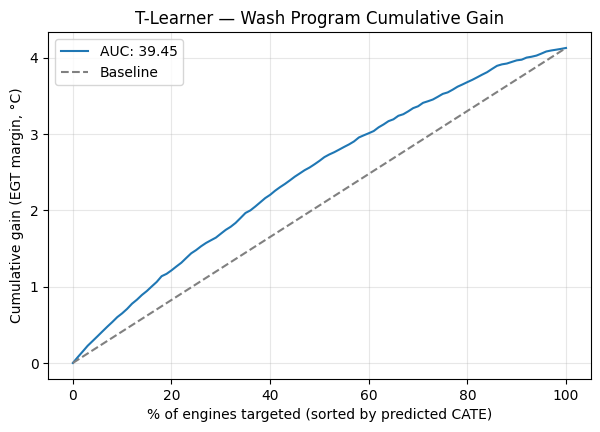

T-Learner PEHE: 0.2621590284543147


In [6]:
np.random.seed(123)
m0 = LGBMRegressor(verbosity=-1)
m1 = LGBMRegressor(verbosity=-1)

m0.fit(train.query(f"{T}==0")[X], train.query(f"{T}==0")[y])
m1.fit(train.query(f"{T}==1")[X], train.query(f"{T}==1")[y])

t_learner_pred = test.assign(cate=m1.predict(test[X]) - m0.predict(test[X]))

auc_t = plot_cumulative_gain(t_learner_pred, "cate", y, T, "T-Learner — Wash Program Cumulative Gain")
plt.show()
print("T-Learner PEHE:", pehe(test["true_cate"], t_learner_pred["cate"]))


## 4. X-Learner — correcting for the small-pilot-trial imbalance

Enrollment isn't 50/50 in the fleet data, and in reality a new maintenance
program almost always starts on a **small pilot group of aircraft** before
scaling fleet-wide. The X-Learner's propensity-weighted second stage
handles this kind of imbalance explicitly.


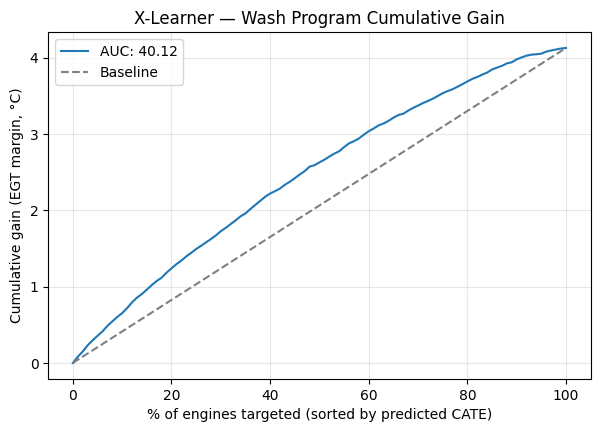

X-Learner PEHE: 0.1366112822771984


In [7]:
np.random.seed(123)

ps_model = LogisticRegression(max_iter=1000)
ps_model.fit(train[X], train[T])

train_t0 = train.query(f"{T}==0")
train_t1 = train.query(f"{T}==1")

m0 = LGBMRegressor(verbosity=-1)
m1 = LGBMRegressor(verbosity=-1)
m0.fit(train_t0[X], train_t0[y])
m1.fit(train_t1[X], train_t1[y])

tau_hat_0 = m1.predict(train_t0[X]) - train_t0[y]
tau_hat_1 = train_t1[y] - m0.predict(train_t1[X])

m_tau_0 = LGBMRegressor(verbosity=-1)
m_tau_1 = LGBMRegressor(verbosity=-1)
m_tau_0.fit(train_t0[X], tau_hat_0)
m_tau_1.fit(train_t1[X], tau_hat_1)

ps_test = ps_model.predict_proba(test[X])[:, 1]
x_learner_pred = test.assign(
    cate=ps_test * m_tau_0.predict(test[X]) + (1 - ps_test) * m_tau_1.predict(test[X])
)

auc_x = plot_cumulative_gain(x_learner_pred, "cate", y, T, "X-Learner — Wash Program Cumulative Gain")
plt.show()
print("X-Learner PEHE:", pehe(test["true_cate"], x_learner_pred["cate"]))


In [8]:
pd.DataFrame({
    "T-Learner": dict(AUC=auc_t, PEHE=pehe(test["true_cate"], t_learner_pred["cate"])),
    "X-Learner": dict(AUC=auc_x, PEHE=pehe(test["true_cate"], x_learner_pred["cate"])),
}).T


,AUC,PEHE
T-Learner,39.445161,0.262159
X-Learner,40.123365,0.136611


## 5. Reproducing the book's regularization-bias experiment with a realistic small-fleet pilot

New MRO programs are typically trialled on a handful of tail numbers before
a fleet-wide rollout. Let's simulate exactly that: only **3% of
engine-months** are enrolled, the baseline EGT-margin surface is nonlinear
in `particulate_index` (a sharp effect right around moderate dust exposure,
where fouling-vs-cleaning dynamics are most sensitive), and the true wash
effect is **constant** — the setup the book uses to expose T-Learner
regularization bias.


In [9]:
def simulate_pilot_fleet(n=4000, enroll_share=0.03, seed=1):
    rng = np.random.default_rng(seed)
    dust = rng.uniform(-1, 1, n)              # standardized particulate exposure
    T = rng.binomial(1, enroll_share, n)

    mu0 = 0.4 * np.exp(-30 * dust ** 2)       # sharp nonlinearity around moderate dust
    tau_true = np.ones(n) * 1.0               # CONSTANT true benefit
    noise = rng.normal(0, 0.05, n)

    Y = mu0 + T * tau_true + noise
    return pd.DataFrame(dict(dust=dust, T=T, Y=Y, tau_true=tau_true))


pilot_fleet = simulate_pilot_fleet()
pf_train, pf_test = pilot_fleet.iloc[: len(pilot_fleet)//2], pilot_fleet.iloc[len(pilot_fleet)//2:]
print("Engine-months enrolled in the small pilot (training set):", pf_train['T'].sum(), "/", len(pf_train))


Engine-months enrolled in the small pilot (training set): 60 / 2000


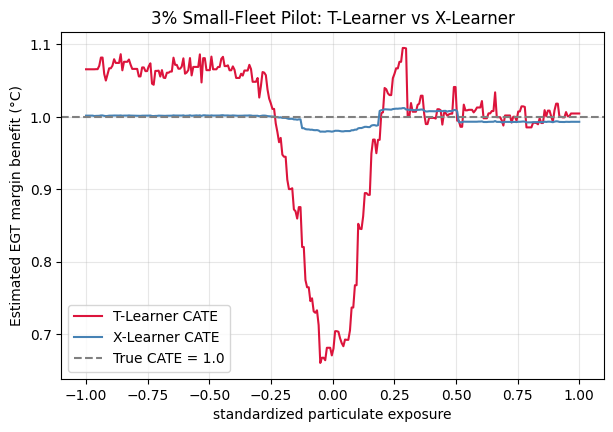

T-Learner PEHE (3% pilot): 0.10870946838185029
X-Learner PEHE (3% pilot): 0.008589909090666826


In [10]:
np.random.seed(123)
m0_p = LGBMRegressor(min_child_samples=25, verbosity=-1)
m1_p = LGBMRegressor(min_child_samples=25, verbosity=-1)
m0_p.fit(pf_train.query("T==0")[["dust"]], pf_train.query("T==0")["Y"])
m1_p.fit(pf_train.query("T==1")[["dust"]], pf_train.query("T==1")["Y"])

grid = pd.DataFrame({"dust": np.linspace(-1, 1, 300)})
mu0_hat = m0_p.predict(grid)
mu1_hat = m1_p.predict(grid)
t_learner_cate_pilot = mu1_hat - mu0_hat

ps_model_p = LogisticRegression(max_iter=1000)
ps_model_p.fit(pf_train[["dust"]], pf_train["T"])

t0p = pf_train.query("T==0")
t1p = pf_train.query("T==1")
tau_hat_0_p = m1_p.predict(t0p[["dust"]]) - t0p["Y"]
tau_hat_1_p = t1p["Y"] - m0_p.predict(t1p[["dust"]])

m_tau0_p = LGBMRegressor(verbosity=-1)
m_tau1_p = LGBMRegressor(verbosity=-1)
m_tau0_p.fit(t0p[["dust"]], tau_hat_0_p)
m_tau1_p.fit(t1p[["dust"]], tau_hat_1_p)

ps_grid_p = ps_model_p.predict_proba(grid)[:, 1]
x_learner_cate_pilot = ps_grid_p * m_tau0_p.predict(grid) + (1 - ps_grid_p) * m_tau1_p.predict(grid)

fig, ax = plt.subplots()
ax.plot(grid["dust"], t_learner_cate_pilot, color="crimson", label="T-Learner CATE")
ax.plot(grid["dust"], x_learner_cate_pilot, color="steelblue", label="X-Learner CATE")
ax.axhline(1.0, color="gray", linestyle="--", label="True CATE = 1.0")
ax.legend()
ax.set_title("3% Small-Fleet Pilot: T-Learner vs X-Learner")
ax.set_xlabel("standardized particulate exposure")
ax.set_ylabel("Estimated EGT margin benefit (\N{DEGREE SIGN}C)")
plt.show()

print("T-Learner PEHE (3% pilot):", pehe(pf_test["tau_true"],
      np.interp(pf_test["dust"], grid["dust"], t_learner_cate_pilot)))
print("X-Learner PEHE (3% pilot):", pehe(pf_test["tau_true"],
      np.interp(pf_test["dust"], grid["dust"], x_learner_cate_pilot)))


Same story as the book, in an MRO setting: with only 3% of engine-months
enrolled, $\hat\mu_1$ (the sparse treated-only model) can't afford to fit
the sharp nonlinearity that $\hat\mu_0$ (abundant control data) picks up
cleanly — so the T-Learner's CATE estimate incorrectly dips right where the
outcome surface bends, even though the true benefit is flat. The
X-Learner's propensity weighting down-weights the noisy treated-only model
and tracks the true constant benefit far more closely — exactly the
situation a real small-fleet pilot program starts in.


# Part 2 — Continuous treatment: how many washes per 500 flight cycles?

Now the second decision. `wash_obs` is a **large, confounded**
observational dataset: wash interval was set by a **"chase the problem"**
maintenance policy — engines already trending toward fast SFC degradation
get washed more often, engines trending well get washed less. That
correlates wash frequency with (already declining) baseline efficiency — a
different, trickier confound than simple targeting-by-environment.
`wash_rnd` is a **small randomized** interval trial used only for
evaluation.

**Outcome:** `sfc_improvement_pct` — specific fuel consumption improvement
(%) relative to a never-washed baseline (higher = more fuel-efficient).
**Treatment:** `washes_per_500cyc` (continuous, 0–6).
**True effect design:** benefit per wash **rises with particulate
exposure** but **saturates** at very high exposure, where structural
erosion (not just removable fouling) starts to dominate the SFC penalty and
washing can no longer fully compensate — a realistic diminishing-returns
shape.


In [11]:
def simulate_wash_engines(n, seed):
    rng = np.random.default_rng(seed)
    baseline_sfc_trend = rng.gamma(3, 1.0, n).clip(0, 15)   # % SFC degradation trend w/o intervention
    particulate_index = rng.beta(2, 3, n) * 10
    engine_cycles = rng.exponential(6000, n).clip(200, 30000)
    return pd.DataFrame(dict(
        baseline_sfc_trend=baseline_sfc_trend,
        particulate_index=particulate_index,
        engine_cycles=engine_cycles,
    ))


def assign_wash_interval_confounded(Xw, rng):
    # "Chase the problem": engines with a worse SFC trend get washed more often.
    mean_interval = (0.9 + 0.35 * Xw["baseline_sfc_trend"]).clip(0, 6)
    interval = rng.normal(mean_interval, 0.8).clip(0, 6)
    return interval


def wash_sensitivity(Xw):
    # Benefit per wash rises with particulate exposure, then saturates
    # (diminishing returns once structural erosion dominates).
    idx = Xw["particulate_index"]
    return 0.15 + 0.55 * (1 - np.exp(-idx / 4))


def simulate_sfc_outcome(Xw, interval, rng):
    sens = wash_sensitivity(Xw)
    Y = (
        -0.3 * Xw["baseline_sfc_trend"]           # unwashed baseline: efficiency erodes with fouling trend
        + sens * interval
        - 0.01 * Xw["engine_cycles"] / 1000        # general age-related SFC penalty
        + rng.normal(0, 0.6, len(Xw))
    )
    return Y, sens


rng = np.random.default_rng(9)

# --- Confounded observational wash-interval data ---
Xw_obs = simulate_wash_engines(300_000, seed=51)
interval_obs = assign_wash_interval_confounded(Xw_obs, rng)
Y_obs, sens_obs = simulate_sfc_outcome(Xw_obs, interval_obs, rng)
wash_obs = Xw_obs.assign(washes_per_500cyc=interval_obs, sfc_improvement_pct=Y_obs)

# --- Randomized wash-interval trial, evaluation only ---
Xw_rnd = simulate_wash_engines(10_000, seed=52)
interval_rnd = rng.uniform(0, 6, len(Xw_rnd))
Y_rnd, sens_rnd_true = simulate_sfc_outcome(Xw_rnd, interval_rnd, rng)
wash_rnd = Xw_rnd.assign(washes_per_500cyc=interval_rnd, sfc_improvement_pct=Y_rnd, true_sensitivity=sens_rnd_true)

print(len(wash_obs), len(wash_rnd))
wash_rnd.head()


300000 10000


,baseline_sfc_trend,particulate_index,engine_cycles,washes_per_500cyc,sfc_improvement_pct,true_sensitivity
0,1.532514,2.976842,6764.566855,1.715652,-0.167321,0.438690
1,2.563751,0.945263,1076.726523,5.076204,0.981895,0.265758
2,3.230503,2.979999,10452.973304,3.564390,0.566577,0.438896
3,2.988229,4.063544,7898.502212,3.013024,1.080987,0.500855
4,1.207228,6.050094,3497.413883,4.923584,3.375771,0.578806


In [12]:
w_train, w_test = wash_obs, wash_rnd
Xw = ["baseline_sfc_trend", "particulate_index", "engine_cycles"]
Tw = "washes_per_500cyc"
yw = "sfc_improvement_pct"

print("Correlation between wash interval and baseline SFC trend (confounded data):",
      np.corrcoef(w_train[Tw], w_train["baseline_sfc_trend"])[0, 1])


Correlation between wash interval and baseline SFC trend (confounded data): 0.6068689339502387


As expected, engines with a **worse** baseline fouling trend get washed
**more** in the observational data — the opposite direction of the true
benefit relationship, which is exactly why a naive regression here can be
badly misleading about the *marginal* value of an extra wash.


## 6. S-Learner — a single model with wash interval as a feature

We fit one model with interval as a feature, build a grid of candidate
intervals, and summarize each engine's coarse dose-response curve into a
single CATE-like slope: $\hat\beta = \mathrm{Cov}(t,y)/\mathrm{Var}(t)$
— the book's approach for continuous-treatment S-Learners.


In [13]:
np.random.seed(123)
s_learner = LGBMRegressor(verbosity=-1)
s_learner.fit(w_train[Xw + [Tw]], w_train[yw])

interval_grid = pd.DataFrame(dict(key=1, washes_per_500cyc=[0, 1, 2, 3, 4, 5, 6]))

test_cf = (
    w_test
    .drop(columns=[Tw])
    .assign(key=1)
    .reset_index().rename(columns={"index": "engine_id"})
    .merge(interval_grid, on="key")
    .drop(columns="key")
)
test_cf["sfc_hat"] = s_learner.predict(test_cf[Xw + [Tw]])
test_cf.head(7)


,engine_id,baseline_sfc_trend,particulate_index,engine_cycles,sfc_improvement_pct,true_sensitivity,washes_per_500cyc,sfc_hat
0,0,1.532514,2.976842,6764.566855,-0.167321,0.43869,0,-0.551341
1,0,1.532514,2.976842,6764.566855,-0.167321,0.43869,1,-0.079152
2,0,1.532514,2.976842,6764.566855,-0.167321,0.43869,2,0.396126
3,0,1.532514,2.976842,6764.566855,-0.167321,0.43869,3,0.752225
4,0,1.532514,2.976842,6764.566855,-0.167321,0.43869,4,1.236104
5,0,1.532514,2.976842,6764.566855,-0.167321,0.43869,5,1.433546
6,0,1.532514,2.976842,6764.566855,-0.167321,0.43869,6,1.433546


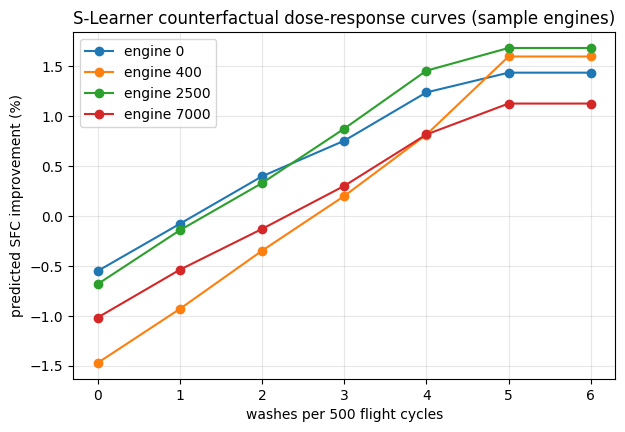

In [14]:
sample_engines = w_test.reset_index().rename(columns={"index": "engine_id"}).iloc[[0, 400, 2500, 7000]]["engine_id"].values

fig, ax = plt.subplots()
for eid in sample_engines:
    curve = test_cf.query("engine_id == @eid").sort_values("washes_per_500cyc")
    ax.plot(curve["washes_per_500cyc"], curve["sfc_hat"], marker="o", label=f"engine {eid}")
ax.set_xlabel("washes per 500 flight cycles")
ax.set_ylabel("predicted SFC improvement (%)")
ax.set_title("S-Learner counterfactual dose-response curves (sample engines)")
ax.legend()
plt.show()


In [15]:
@curry
def linear_effect(df, y, t):
    return np.cov(df[y], df[t])[0, 1] / np.var(df[t])


cate_slope = (
    test_cf
    .groupby("engine_id")
    .apply(linear_effect(y="sfc_hat", t="washes_per_500cyc"), include_groups=False)
    .rename("cate")
)

s_learner_pred = w_test.reset_index().rename(columns={"index": "engine_id"}).set_index("engine_id").join(cate_slope)
print("S-Learner PEHE (slope vs true marginal sensitivity):",
      pehe(s_learner_pred["true_sensitivity"], s_learner_pred["cate"]))
s_learner_pred.head()


S-Learner PEHE (slope vs true marginal sensitivity): 0.042559128928390456


,baseline_sfc_trend,particulate_index,engine_cycles,washes_per_500cyc,sfc_improvement_pct,true_sensitivity,cate
engine_id,,,,,,,
0,1.532514,2.976842,6764.566855,1.715652,-0.167321,0.438690,0.409168
1,2.563751,0.945263,1076.726523,5.076204,0.981895,0.265758,0.249498
2,3.230503,2.979999,10452.973304,3.564390,0.566577,0.438896,0.443208
3,2.988229,4.063544,7898.502212,3.013024,1.080987,0.500855,0.466517
4,1.207228,6.050094,3497.413883,4.923584,3.375771,0.578806,0.579473


## 7. R-Learner / Double-ML — orthogonalized marginal wash-benefit

$$\tilde T = T - \hat\mu_t(X), \qquad \tilde Y = Y - \hat\mu_y(X), \qquad
Y^* = \tilde Y / \tilde T \ \text{(weighted by } \tilde T^2\text{)}$$


In [16]:
np.random.seed(123)

debias_m = LGBMRegressor(verbosity=-1)   # predicts wash interval from X
denoise_m = LGBMRegressor(verbosity=-1)  # predicts SFC improvement from X

t_res = w_train[Tw] - cross_val_predict(debias_m, w_train[Xw], w_train[Tw], cv=5)
y_res = w_train[yw] - cross_val_predict(denoise_m, w_train[Xw], w_train[yw], cv=5)

print("Naive OLS slope (confounded 'chase the problem' data):",
      sm.OLS(w_train[yw], sm.add_constant(w_train[Tw])).fit().params.iloc[1])
print("Double-ML orthogonalized ATE (avg. marginal effect per wash):",
      sm.OLS(y_res, t_res).fit().params.iloc[0])
print("True average marginal sensitivity:",
      wash_sensitivity(pd.concat([Xw_obs, Xw_rnd])).mean())


Naive OLS slope (confounded 'chase the problem' data): 0.1537874984304106
Double-ML orthogonalized ATE (avg. marginal effect per wash): 0.4701842897947144
True average marginal sensitivity: 0.4723269383588726


Because planners wash the *worst-trending* engines more, the naive slope
badly understates the true marginal value of a wash. The orthogonalized
Double-ML estimate lands much closer to the true average sensitivity.


R-Learner PEHE: 0.02632364436281465


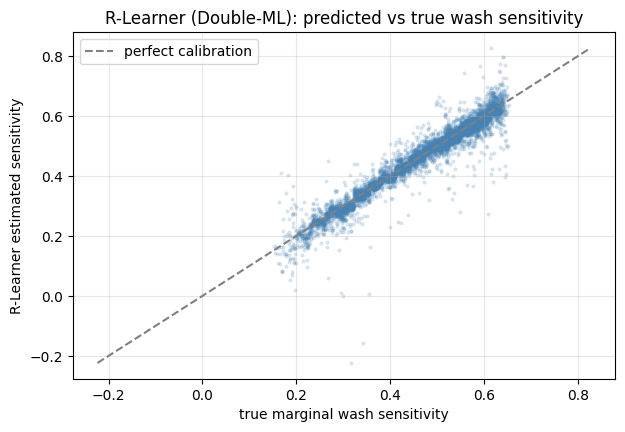

In [17]:
np.random.seed(123)
y_star = y_res / t_res
w = t_res ** 2

r_learner = LGBMRegressor(verbosity=-1)
r_learner.fit(w_train[Xw], y_star, sample_weight=w)

r_learner_pred = w_test.assign(cate=r_learner.predict(w_test[Xw]))

print("R-Learner PEHE:", pehe(r_learner_pred["true_sensitivity"], r_learner_pred["cate"]))

fig, ax = plt.subplots()
ax.scatter(r_learner_pred["true_sensitivity"], r_learner_pred["cate"], s=4, alpha=0.15, color="steelblue")
lims = [r_learner_pred[["true_sensitivity", "cate"]].min().min(),
        r_learner_pred[["true_sensitivity", "cate"]].max().max()]
ax.plot(lims, lims, "--", color="gray", label="perfect calibration")
ax.set_xlabel("true marginal wash sensitivity")
ax.set_ylabel("R-Learner estimated sensitivity")
ax.set_title("R-Learner (Double-ML): predicted vs true wash sensitivity")
ax.legend()
plt.show()


In [18]:
pd.DataFrame({
    "S-Learner": dict(PEHE=pehe(s_learner_pred["true_sensitivity"], s_learner_pred["cate"])),
    "R-Learner": dict(PEHE=pehe(r_learner_pred["true_sensitivity"], r_learner_pred["cate"])),
}).T


,PEHE
S-Learner,0.042559
R-Learner,0.026324


The R-Learner should come out clearly more accurate here — the
"chase-the-problem" confounding is strong enough that a single S-Learner
model, without explicit orthogonalization, has a harder time isolating the
true marginal wash effect from the baseline degradation trend it's
correlated with.


# Part 3 — Turning both into MRO operating decisions

## 8. Wash program enrollment: a shop-visit-slot-constrained plan

Suppose the MRO shop can only handle enrolling **25% of engines** into the
preventive wash program in the next planning cycle (labor and
aircraft-on-ground time are the constraint, not engine willingness).
Using the X-Learner's CATE ranking to pick the top 25% instead of enrolling
by seniority or arbitrary fleet rotation:


In [19]:
x_pct, gains = cumulative_gain_curve(x_learner_pred, "cate", y, T)
gain_at_25 = np.interp(25, x_pct, gains)
random_gain_at_25 = gains[-1] * 0.25

print(f"Estimated EGT margin gain (\N{DEGREE SIGN}C) from enrolling the top 25% by predicted benefit: {gain_at_25:,.3f}")
print(f"Estimated EGT margin gain (\N{DEGREE SIGN}C) from enrolling a random 25%:                      {random_gain_at_25:,.3f}")
print(f"Uplift from targeting vs. random enrollment: {100*(gain_at_25/random_gain_at_25 - 1):.1f}%")


Estimated EGT margin gain (°C) from enrolling the top 25% by predicted benefit: 1.492
Estimated EGT margin gain (°C) from enrolling a random 25%:                      1.032
Uplift from targeting vs. random enrollment: 44.6%


## 9. Wash interval policy: per-engine frequency under a wash-hours budget

Using the R-Learner's per-engine sensitivity, allocate more frequent washes
to high-sensitivity engines and fewer to low-sensitivity ones, subject to
an average interval budget the MRO team can actually staff (e.g., average
≤ 2.5 washes per 500 cycles across the fleet).


In [20]:
budget = 2.5  # average washes per 500 cycles across the fleet

raw = r_learner_pred["cate"].clip(lower=0.05)
alloc = raw / raw.mean() * budget
alloc = alloc.clip(0, 6)

policy = r_learner_pred.assign(recommended_interval=alloc)

print("Average recommended wash interval (should be close to budget):", policy["recommended_interval"].mean())
print("\nRecommended interval by true-sensitivity tercile (sanity check — should increase with sensitivity):")
policy["sensitivity_tercile"] = pd.qcut(policy["true_sensitivity"], 3, labels=["low", "mid", "high"])
policy.groupby("sensitivity_tercile")["recommended_interval"].mean()


Average recommended wash interval (should be close to budget): 2.5

Recommended interval by true-sensitivity tercile (sanity check — should increase with sensitivity):


sensitivity_tercile
low     1.838156
mid     2.601656
high    3.060387
Name: recommended_interval, dtype: float64

The policy correctly allocates **more frequent washes to the
high-sensitivity tercile** — engines flying dustier routes where a wash
recovers the most efficiency — rather than to whichever engines happened to
already be trending worst, which was the old "chase the problem" logic.


## 10. Key takeaways / decision guide

| Decision | Treatment type | Learner(s) used | Why |
|---|---|---|---|
| Wash program enrollment | Binary (enrolled / not) | T-Learner, **X-Learner** | New MRO programs almost always start on a small pilot fleet (few treated); X-Learner corrects the resulting regularization bias |
| Wash interval | Continuous (0–6 washes/500 cyc) | S-Learner, **R-Learner (Double-ML)** | "Chase the problem" maintenance policies confound naive frequency-vs-benefit regressions; orthogonalization isolates the true marginal effect |

**Practical lessons that generalize to other MRO/reliability problems:**

- **Preventive-maintenance programs are confounded by design.** Planners
  don't enroll assets at random — they target the ones that look like they
  need it most, which is exactly the assignment mechanism that breaks naive
  before/after or treated/untreated comparisons on historical data.
- **New programs start small.** A pilot fleet, a trial route, a handful of
  tail numbers — any staged rollout is inherently the "few treated / many
  control" scenario, which is why the **X-Learner** is usually the safer
  default over the T-Learner during early-stage maintenance-program
  evaluation.
- **"Chase the problem" policies reverse the naive correlation.** When the
  historical assignment mechanism *responds* to the outcome trend (wash
  more because SFC is degrading), a naive regression can get the direction
  of the relationship wrong. Orthogonalization (R-Learner/Double-ML) is
  built precisely for this kind of reverse-causality-flavored confounding.
- **Continuous maintenance dosing needs a dose-response answer, not a
  yes/no one.** The real MRO question is rarely just "wash or don't" — it's
  "how often, for this specific engine, given a fixed maintenance budget" —
  which is what the R-Learner's marginal-effect estimates are built to
  answer.
- **A randomized pilot trial is worth protecting.** Every claim in this
  notebook about which learner performed better, what the true enrollment
  benefit is, and what the true wash sensitivity looks like depended on
  `data_pilot` / `wash_rnd` — the model has no way to grade its own
  homework without it.
